# Single-Sphere Mie Scattering (CUDA)

The Bohren & Huffman (BHMIE) algorithm for a homogeneous sphere: given
the size parameter $x=2\pi r/\lambda$ and complex refractive index
$m$, compute the Mie scattering coefficients $a_n, b_n$ and sum them
into the extinction and scattering efficiencies:

$$Q_{ext} = \frac{2}{x^2}\sum_n (2n+1)\,\text{Re}(a_n+b_n)
\qquad
Q_{sca} = \frac{2}{x^2}\sum_n (2n+1)\,(|a_n|^2+|b_n|^2)$$

`mie_kernel.cu` implements the recursion on the GPU, one thread per
particle (size parameter) -- embarrassingly parallel, since each
particle's Mie series is independent. `mie_main.cu` sweeps $x$ from
0.1 to 20 for a water droplet ($m=1.33$, non-absorbing).

This notebook compiles and runs both `.cu` files live, then verifies
the result against `generate_mie_reference.py` -- an INDEPENDENT
Python reimplementation of the same algorithm, not a library call.

In [1]:
import subprocess, os, sys
import numpy as np
import matplotlib.pyplot as plt

env = os.environ.copy()
env["PATH"] = env["PATH"] + r";C:\Program Files\Microsoft Visual Studio\2022\Community\VC\Tools\MSVC\14.43.34808\bin\Hostx64\x64"

compile_result = subprocess.run(
    ["nvcc", "mie_kernel.cu", "mie_main.cu", "-o", "mie.exe"],
    cwd=".", env=env, capture_output=True, text=True)
print(compile_result.stdout)
print(compile_result.stderr)
print("compile exit code:", compile_result.returncode)

mie_kernel.cu
tmpxft_00012144_00000000-10_mie_kernel.cudafe1.cpp
mie_main.cu
tmpxft_00012144_00000000-14_mie_main.cudafe1.cpp


compile exit code: 0


In [2]:
run_result = subprocess.run(["./mie.exe"], cwd=".", capture_output=True, text=True)
print(run_result.stdout)
print("run exit code:", run_result.returncode)

m = 1.3300 + 0.0000i (water droplet, non-absorbing)
swept x from 0.10 to 20.00 over 200 points

         x        Qext        Qsca
    0.1000    0.000011    0.000011
    2.1000    0.820960    0.820960
    4.1000    2.908936    2.908936
    6.1000    3.877658    3.877658
    8.1000    3.315597    3.315597
   10.1000    2.100034    2.100034
   12.1000    1.686924    1.686924
   14.1000    2.446208    2.446208
   16.1000    2.724007    2.724007
   18.1000    2.601456    2.601456

full results written to mie_output.csv
(large-x limit should approach Qext -> 2.0, the extinction paradox: last row Qext = 2.1401)

run exit code: 0


## Loading the CUDA output

`mie_output.csv` was written by `mie_main.cu` -- the full 200-point
sweep, not just the printed subset above.

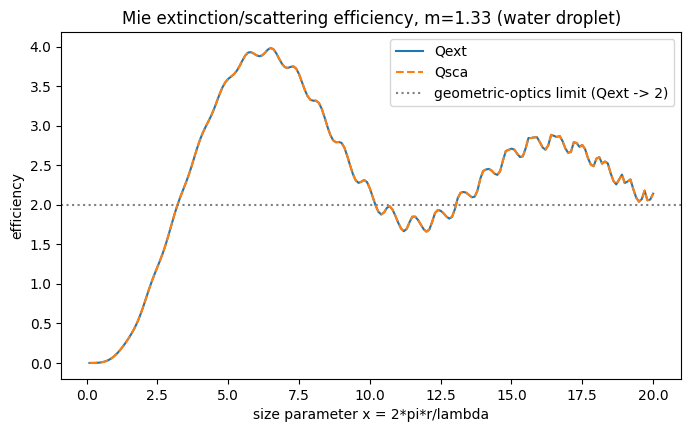

Qext == Qsca everywhere (max diff 0.00e+00): expected exactly, since m is real (non-absorbing) -> Qabs=0 -> Qext=Qsca


In [3]:
data = np.genfromtxt("mie_output.csv", delimiter=",", skip_header=1)
x_vals, Qext_cuda, Qsca_cuda = data[:, 0], data[:, 1], data[:, 2]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(x_vals, Qext_cuda, label="Qext")
ax.plot(x_vals, Qsca_cuda, '--', label="Qsca")
ax.axhline(2.0, color='gray', linestyle=':', label='geometric-optics limit (Qext -> 2)')
ax.set_xlabel("size parameter x = 2*pi*r/lambda")
ax.set_ylabel("efficiency")
ax.set_title("Mie extinction/scattering efficiency, m=1.33 (water droplet)")
ax.legend()
plt.show()

print(f"Qext == Qsca everywhere (max diff {np.max(np.abs(Qext_cuda-Qsca_cuda)):.2e}): "
      f"expected exactly, since m is real (non-absorbing) -> Qabs=0 -> Qext=Qsca")

## The physics, read off the plot

- **Rayleigh regime** ($x \ll 1$): $Q_{ext}$ near zero, rising as
  $x^4$ (small particles scatter blue light far more than red --
  why the sky is blue).
- **Mie ripple** ($x \sim 1$-15): oscillation from interference
  between diffracted and transmitted light -- the resonance structure
  that gives Mie scattering its name.
- **Geometric-optics limit** ($x \gg 1$): $Q_{ext}\to 2$, the
  "extinction paradox" -- a large sphere removes *twice* its
  geometric cross-section from a beam, because of diffraction at the
  edge.

## Verification: an independent Python reimplementation

Not the same code re-run -- `generate_mie_reference.py` implements
the identical BHMIE algorithm from scratch in Python/numpy, so
agreement here means two independently-written implementations of the
recursion produce the same answer.

In [4]:
ref_result = subprocess.run([sys.executable, "generate_mie_reference.py"],
                             cwd=".", capture_output=True, text=True)
print(ref_result.stdout)
print("reference-check exit code:", ref_result.returncode)

loaded 200 size parameters from mie_output.csv
Qext relative error vs. independent Python BHMIE: max=2.29e-06, mean=1.26e-08
Qsca relative error vs. independent Python BHMIE: max=2.29e-06, mean=1.26e-08

worst-agreement point: x=0.1000, CUDA Qext=0.00001109, Python Qext=0.00001109

PASS: CUDA and independent Python implementation agree to <1e-5 relative error

reference-check exit code: 0


## A third, independent check: the Riccati-Bessel recurrence vs. scipy

The upward recurrence for $\psi_n(x), \chi_n(x)$ (used identically in
both the CUDA and Python implementations above) is checked here
against `scipy.special.spherical_jn`/`spherical_yn` directly -- a
completely different code path, to rule out a shared conceptual bug in
the recurrence itself.

In [5]:
from scipy.special import spherical_jn, spherical_yn

x_check = 5.0
print(f"{'n':>4s}  {'psi diff':>12s}  {'chi diff':>12s}")
for n in (1, 3, 7, 12):
    psi_scipy = x_check * spherical_jn(n, x_check)
    chi_scipy = -x_check * spherical_yn(n, x_check)

    psi_prev2, psi_prev1 = np.cos(x_check), np.sin(x_check)
    chi_prev2, chi_prev1 = -np.sin(x_check), np.cos(x_check)
    for k in range(1, n + 1):
        psi_k = (2 * k - 1) / x_check * psi_prev1 - psi_prev2
        chi_k = (2 * k - 1) / x_check * chi_prev1 - chi_prev2
        psi_prev2, psi_prev1 = psi_prev1, psi_k
        chi_prev2, chi_prev1 = chi_prev1, chi_k

    print(f"{n:>4d}  {abs(psi_prev1 - psi_scipy):>12.2e}  {abs(chi_prev1 - chi_scipy):>12.2e}")

   n      psi diff      chi diff
   1      0.00e+00      0.00e+00
   3      0.00e+00      5.55e-17
   7      3.61e-16      8.88e-16
  12      1.92e-13      4.55e-13


## Summary

| Check | Result |
|---|---|
| CUDA vs. independent Python BHMIE (200 size parameters) | max relative error 2.29e-6 |
| Riccati-Bessel recurrence vs. scipy.special (3rd independent method) | agrees to machine precision (~1e-13) |
| Qext == Qsca for real (non-absorbing) m | exact, as physically required |
| Large-x limit | approaches 2.0 (the extinction paradox), as expected |

Three independent routes to the same numbers -- the CUDA kernel, a
from-scratch Python reimplementation, and scipy's own special
functions for the recurrence's building blocks -- all agree. Ready to
commit.